In [2]:
class Perceptron:
    def __init__(self, learning_rate = 1):
        self.w1=0
        self.w2=0
        self.learning_rate = learning_rate
        self.bias = 0

    def predict(self, x1, x2):
        # weighted sum
        z = self.w1 * x1 + self.w2 * x2 + self.bias
        # step function
        if z >= 0:
            return 1
        else:
            return 0

    def train(self, X, y, epochs=100):
        for epoch in range(epochs):

            errors = 0

            for i in range(len(X)):

                x1 = X[i][0]
                x2 = X[i][1]

                prediction = self.predict(x1, x2)

                error = y[i] - prediction

                if error!=0:
                    # Update weights
                    self.w1 += self.learning_rate * error * x1
                    self.w2 += self.learning_rate * error * x2
                    self.bias += self.learning_rate * error
                    errors+=1
            
            # Stop if everything is correct
            if errors == 0:
                print("Training completed at epoch:", epoch + 1)
                break

In [3]:
import pandas as pd

df = pd.read_csv("student_placement_100.csv")

print(df.shape)
print(df.head(5))

# 80% training
train = df[:80]

# 20% testing
test = df[80:]

# -------------------------
# TRAINING DATA
# -------------------------

X_train = train[["CGPA", "12th_Marks"]].copy()

# Normalize
X_train["CGPA"] = X_train["CGPA"] / 10
X_train["12th_Marks"] = X_train["12th_Marks"] / 100

X_train_data = X_train.values
y_train_data = train["Placement"].values


# -------------------------
# TESTING DATA
# -------------------------

X_test = test[["CGPA", "12th_Marks"]].copy()

# Normalize in exactly the same way
X_test["CGPA"] = X_test["CGPA"] / 10
X_test["12th_Marks"] = X_test["12th_Marks"] / 100

X_test_data = X_test.values
y_test_data = test["Placement"].values

(100, 3)
   CGPA  12th_Marks  Placement
0  8.20       51.25          0
1  6.38       61.16          0
2  8.68       83.83          1
3  9.46       54.35          0
4  7.11       51.49          0


In [4]:
p = Perceptron(learning_rate=0.1)
p.train(X_train_data, y_train_data, epochs=100)

In [9]:
correct = 0
for i in range(len(X_test_data)):
    result = p.predict(X_test_data[i][0], X_test_data[i][1])

    print(
        "Actual:", y_test_data[i],
        "Predicted:", result
    )

    if result == y_test_data[i]:
        correct += 1

accuracy = correct / len(X_test_data)

print("Accuracy:", accuracy * 100, "%")

print("w1:", p.w1)
print("w2:", p.w2)
print("bias:", p.bias)

Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 0 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 1 Predicted: 1
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Accuracy: 95.0 %
w1: 1.320000000000004
w2: 1.0521600000000073
bias: -1.8000000000000005


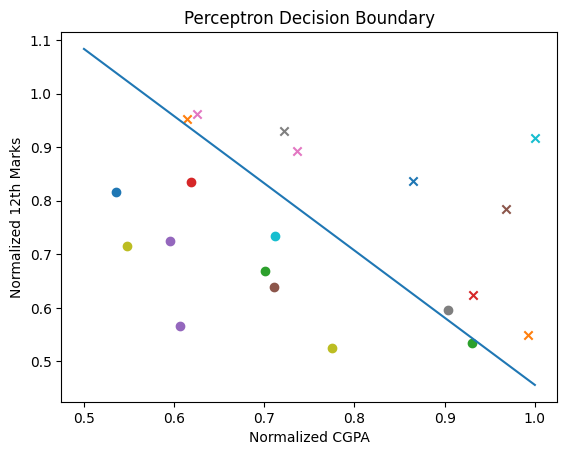

In [6]:
import matplotlib.pyplot as plt

# Plot students
for i in range(len(X_test_data)):
    if y_test_data[i] == 0:
        plt.scatter(X_test_data[i][0], X_test_data[i][1], marker="o")
    else:
        plt.scatter(X_test_data[i][0], X_test_data[i][1], marker="x")

# Decision boundary
x1_values = [0.5, 1.0]

x2_values = [
    -(p.w1 * x + p.bias) / p.w2
    for x in x1_values
]

plt.plot(x1_values, x2_values)

plt.xlabel("Normalized CGPA")
plt.ylabel("Normalized 12th Marks")
plt.title("Perceptron Decision Boundary")

plt.show()